## Task 1.1(a): instalar las librerías en el entorno del kernel.

In [16]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

carpeta_datos = Path("datos")

# Cargar los datasets completos
hospitales = gpd.read_file(carpeta_datos / "hospitales_eeuu.geojson")
condados = gpd.read_file(carpeta_datos / "condados_eeuu.geojson")
poblacion = pd.read_csv(carpeta_datos / "poblacion_condados.csv")
estados = gpd.read_file(carpeta_datos / "estados_eeuu.geojson")

archivos = {
    "hospitales_eeuu.geojson": hospitales,
    "condados_eeuu.geojson": condados,
    "poblacion_condados.csv": poblacion,
    "estados_eeuu.geojson": estados,
}

for nombre, datos in archivos.items():
    print(f"Archivo: {nombre}")
    print(f"Número de registros: {len(datos):,}")

    if isinstance(datos, gpd.GeoDataFrame):
        print(f"CRS: {datos.crs}")
    else:
        print("CRS: No aplica (tabla sin geometría)")

    print("Columnas:", ", ".join(datos.columns))
    print()

Archivo: hospitales_eeuu.geojson
Número de registros: 7,154
CRS: EPSG:4326
Columnas: nombre, tipo, ciudad, estado, condado, fips_condado, camas_total, camas_icu, camas_licenciadas, ocupacion_total, ocupacion_icu, geometry

Archivo: condados_eeuu.geojson
Número de registros: 3,221
CRS: EPSG:4326
Columnas: fips, nombre, cod_estado, geometry

Archivo: poblacion_condados.csv
Número de registros: 3,246
CRS: No aplica (tabla sin geometría)
Columnas: fips, condado, estado, lat, lon, poblacion

Archivo: estados_eeuu.geojson
Número de registros: 51
CRS: EPSG:4326
Columnas: nombre, codigo, pais, geometry



## Task 1.1(b): aplicar las limpiezas antes de filtrar por estado.

In [17]:
#Limpiar la tabla de población y normalizar el código 
fips_numerico = pd.to_numeric(poblacion["fips"], errors="raise")

poblacion_limpia = poblacion.loc[fips_numerico < 80000].copy()
poblacion_limpia["fips"] = (
    fips_numerico.loc[poblacion_limpia.index]
    .astype("int64")
    .astype(str)
    .str.zfill(5)
)

print(f"Registros de población originales: {len(poblacion):,}")
print(f"Registros eliminados: {len(poblacion) - len(poblacion_limpia):,}")
print(f"Registros de población restantes: {len(poblacion_limpia):,}")

#Reportar camas_total nulas 
sin_camas = hospitales["camas_total"].isna()
porcentaje_nulos = sin_camas.mean() * 100

print(f"\nHospitales originales: {len(hospitales):,}")
print(f"Hospitales sin datos de camas totales: {sin_camas.sum():,}")
print(f"Porcentaje con camas_total nulo: {porcentaje_nulos:.2f}%")

#Conservar hospitales con datos disponibles.
hospitales_limpios = hospitales.loc[~sin_camas].copy()

print(f"Hospitales después de la limpieza: {len(hospitales_limpios):,}")

#Contar hospitales disponibles 
hospitales_por_estado = (
    hospitales_limpios.groupby("estado")
    .size()
    .reset_index(name="Hospitales con datos de camas")
    .sort_values("Hospitales con datos de camas", ascending=False)
    .reset_index(drop=True)
)

estados_candidatos = hospitales_por_estado.loc[
    hospitales_por_estado["Hospitales con datos de camas"] >= 50
]

print("\nEstados con al menos 50 hospitales después de la limpieza:")
display(estados_candidatos)

Registros de población originales: 3,246
Registros eliminados: 102
Registros de población restantes: 3,144

Hospitales originales: 7,154
Hospitales sin datos de camas totales: 1,090
Porcentaje con camas_total nulo: 15.24%
Hospitales después de la limpieza: 6,064

Estados con al menos 50 hospitales después de la limpieza:


,estado,Hospitales con datos de camas
0,TX,591
1,CA,440
2,FL,305
3,OH,235
4,PA,231
5,NY,206
6,IL,194
7,LA,190
8,GA,164
9,IN,158


## Task 1.1(c): filtrar Colorado y unir la población con los condados

In [18]:
estado_elegido = "CO"
fips_estado = "08"

# Hospitales de Colorado que tienen datos de camas.
hospitales_estado = hospitales_limpios.loc[
    hospitales_limpios["estado"] == estado_elegido
].copy()

condados = condados.copy()

condados["cod_estado"] = (
    pd.to_numeric(condados["cod_estado"], errors="raise")
    .astype(int).astype(str).str.zfill(2)
)

condados["fips"] = (
    pd.to_numeric(condados["fips"], errors="raise")
    .astype(int).astype(str).str.zfill(5)
)

condados_estado = condados.loc[
    condados["cod_estado"] == fips_estado
].copy()

limite_estado = estados.loc[
    estados["codigo"] == estado_elegido
].copy()

poblacion_estado = poblacion_limpia.loc[
    poblacion_limpia["fips"].str.startswith(fips_estado),
    ["fips", "poblacion"],
].copy()

# Verificar que los códigos coincidan 
fips_geometria = set(condados_estado["fips"])
fips_poblacion = set(poblacion_estado["fips"])

assert fips_geometria == fips_poblacion, (
    f"Sin población: {sorted(fips_geometria - fips_poblacion)}. "
    f"Sin geometría: {sorted(fips_poblacion - fips_geometria)}."
)

condados_estado = condados_estado.merge(
    poblacion_estado,
    on="fips",
    how="left",
    validate="one_to_one",
)

assert condados_estado["poblacion"].notna().all(), (
    "Existen condados con población nula."
)
assert len(limite_estado) == 1, (
    "No se encontró un único límite estatal para Colorado."
)

print("Estado seleccionado: Colorado")
print(f"Hospitales con datos de camas: {len(hospitales_estado)}")
print(f"Condados con geometría: {len(condados_estado)}")
print(f"Condados con población: {len(poblacion_estado)}")
print("Verificación de correspondencia FIPS: PASA")

display(condados_estado[["fips", "nombre", "poblacion"]].head())

Estado seleccionado: Colorado
Hospitales con datos de camas: 99
Condados con geometría: 64
Condados con población: 64
Verificación de correspondencia FIPS: PASA


,fips,nombre,poblacion
0,08003,Alamosa,16233.0
1,08013,Boulder,326196.0
2,08014,Broomfield,70465.0
3,08025,Crowley,6061.0
4,08031,Denver,727211.0


## Task 1.1(d): reproyectar todas las capas espaciales a metros.

In [19]:
crs_proyectado = "EPSG:32613"

hospitales_m = hospitales_estado.to_crs(crs_proyectado)
condados_m = condados_estado.to_crs(crs_proyectado)
estado_m = limite_estado.to_crs(crs_proyectado)

resumen_crs = pd.DataFrame([
    {
        "Capa": nombre,
        "Registros": len(capa),
        "CRS": capa.crs.to_string(),
        "Unidad": capa.crs.axis_info[0].unit_name,
    }
    for nombre, capa in [
        ("Hospitales", hospitales_m),
        ("Condados con población", condados_m),
        ("Límite estatal", estado_m),
    ]
])

display(resumen_crs)

,Capa,Registros,CRS,Unidad
0,Hospitales,99,EPSG:32613,metre
1,Condados con población,64,EPSG:32613,metre
2,Límite estatal,1,EPSG:32613,metre


Se seleccionó el sistema WGS 84 / UTM zona 13N (EPSG:32613) para reproyectar los hospitales, los condados con su población y el límite estatal de Colorado. Este sistema usa metros, lo que permite calcular distancias, áreas y buffers con unidades apropiadas. Su meridiano central, 105° oeste, se encuentra cerca del centro longitudinal
del estado, lo que reduce la distorsión de escala en el territorio. Aunque el extremo occidental de Colorado queda fuera del intervalo habitual de la zona 13N, esta proyección es una aproximación adecuada para el análisis estatal.

## Task 1.1(e): mapa base de Colorado

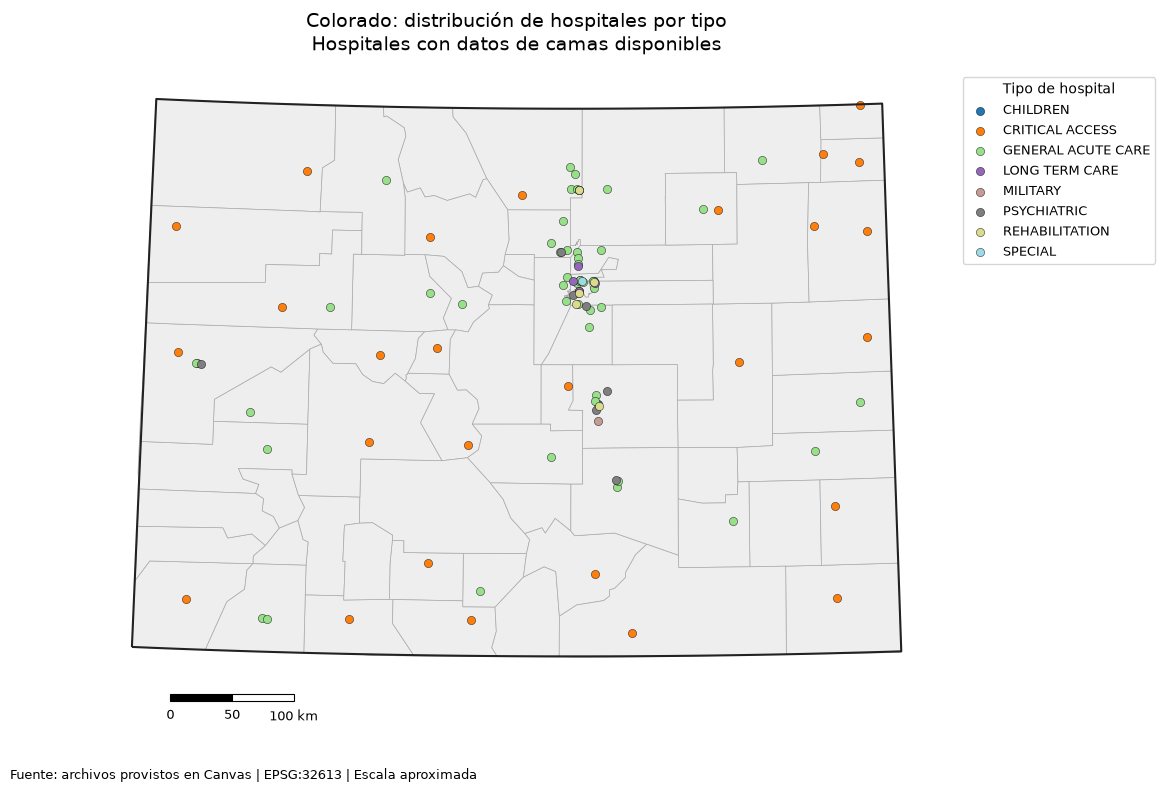

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12, 8))

condados_m.plot(
    ax=ax,
    facecolor="#eeeeee",
    edgecolor="#aaaaaa",
    linewidth=0.5,
)

tipos = sorted(hospitales_m["tipo"].fillna("Sin especificar").unique())
colores = plt.get_cmap("tab20", max(len(tipos), 1))

for i, tipo in enumerate(tipos):
    seleccion = hospitales_m.loc[
        hospitales_m["tipo"].fillna("Sin especificar") == tipo
    ]

    seleccion.plot(
        ax=ax,
        color=colores(i),
        markersize=35,
        edgecolor="black",
        linewidth=0.3,
        label=tipo,
        zorder=3,
    )

estado_m.boundary.plot(
    ax=ax,
    color="#222222",
    linewidth=1.5,
    zorder=4,
)

xmin, ymin, xmax, ymax = estado_m.total_bounds
ancho = xmax - xmin
alto = ymax - ymin

ax.set_xlim(xmin - 0.05 * ancho, xmax + 0.05 * ancho)
ax.set_ylim(ymin - 0.15 * alto, ymax + 0.05 * alto)
ax.set_aspect("equal")

x_escala = xmin + 0.05 * ancho
y_escala = ymin - 0.08 * alto
segmento_m = 50_000
altura_barra = 0.012 * alto

for i, color in enumerate(["black", "white"]):
    ax.add_patch(Rectangle(
        (x_escala + i * segmento_m, y_escala),
        segmento_m,
        altura_barra,
        facecolor=color,
        edgecolor="black",
        linewidth=0.8,
    ))

for i, etiqueta in enumerate(["0", "50", "100 km"]):
    ax.text(
        x_escala + i * segmento_m,
        y_escala - 0.015 * alto,
        etiqueta,
        ha="center",
        va="top",
        fontsize=9,
    )

ax.set_title(
    "Colorado: distribución de hospitales por tipo\n"
    "Hospitales con datos de camas disponibles",
    fontsize=14,
    pad=15,
)

ax.legend(
    title="Tipo de hospital",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=9,
)

ax.set_axis_off()
fig.text(
    0.02, 0.02,
    "Fuente: archivos provistos en Canvas | EPSG:32613 | Escala aproximada",
    fontsize=9,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Task 1.2: estadísticas hospitalarias por condado

In [21]:
hospitales_m = hospitales_m.copy()
hospitales_m["fips_condado"] = (
    pd.to_numeric(hospitales_m["fips_condado"], errors="raise")
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

sin_correspondencia = (
    set(hospitales_m["fips_condado"]) - set(condados_m["fips"])
)

assert not sin_correspondencia, (
    f"Hay hospitales con FIPS sin correspondencia: {sin_correspondencia}"
)

resumen_hospitales = (
    hospitales_m.groupby("fips_condado")
    .agg(
        numero_hospitales=("fips_condado", "size"),
        camas_totales=("camas_total", "sum"),
        camas_uci=(
            "camas_icu",
            lambda valores: valores.sum(min_count=len(valores)),
        ),
    )
    .reset_index()
)

estadisticas_condados = condados_m.merge(
    resumen_hospitales,
    left_on="fips",
    right_on="fips_condado",
    how="left",
    validate="one_to_one",
).drop(columns="fips_condado")

sin_hospitales = estadisticas_condados["numero_hospitales"].isna()

columnas_hospitalarias = [
    "numero_hospitales", "camas_totales", "camas_uci"
]
estadisticas_condados.loc[
    sin_hospitales, columnas_hospitalarias
] = 0

estadisticas_condados["numero_hospitales"] = (
    estadisticas_condados["numero_hospitales"].astype(int)
)

assert (estadisticas_condados["poblacion"] > 0).all(), (
    "Existen poblaciones nulas, iguales a cero o negativas."
)

# Tasas por cada 10,000 habitantes.
estadisticas_condados["camas_por_10000"] = (
    estadisticas_condados["camas_totales"]
    / estadisticas_condados["poblacion"] * 10_000
)

estadisticas_condados["uci_por_10000"] = (
    estadisticas_condados["camas_uci"]
    / estadisticas_condados["poblacion"] * 10_000
)

columnas_reporte = [
    "nombre",
    "numero_hospitales",
    "camas_totales",
    "camas_uci",
    "poblacion",
    "camas_por_10000",
    "uci_por_10000",
]

with pd.option_context("display.max_rows", 70):
    display(
        estadisticas_condados[columnas_reporte]
        .sort_values("nombre")
        .reset_index(drop=True)
        .round(2)
    )

print(
    "Hospitales contabilizados:",
    estadisticas_condados["numero_hospitales"].sum(),
)
print("Condados sin hospitales:", int(sin_hospitales.sum()))
print(
    "Hospitales sin dato de camas UCI:",
    int(hospitales_m["camas_icu"].isna().sum()),
)

,nombre,numero_hospitales,camas_totales,camas_uci,poblacion,camas_por_10000,uci_por_10000
0,Adams,6,1347.0,244.0,517421.0,26.03,4.72
1,Alamosa,1,49.0,6.0,16233.0,30.19,3.70
2,Arapahoe,8,1062.0,NaN,656590.0,16.17,NaN
3,Archuleta,1,11.0,NaN,14029.0,7.84,NaN
4,Baca,1,15.0,NaN,3581.0,41.89,NaN
5,Bent,0,0.0,0.0,5577.0,0.00,0.00
6,Boulder,5,665.0,66.0,326196.0,20.39,2.02
7,Broomfield,1,92.0,20.0,70465.0,13.06,2.84
8,Chaffee,1,25.0,2.0,20356.0,12.28,0.98
9,Cheyenne,1,11.0,NaN,1831.0,60.08,NaN


Hospitales contabilizados: 99
Condados sin hospitales: 17
Hospitales sin dato de camas UCI: 35


## Task 1.2(a): cinco condados con menor disponibilidad de camas

In [22]:
condados_elegibles = estadisticas_condados.loc[
    estadisticas_condados["poblacion"] > 10_000
].copy()

menor_cobertura = (
    condados_elegibles
    .sort_values(["camas_por_10000", "nombre"])
    .head(5)
)

display(
    menor_cobertura[
        [
            "nombre",
            "poblacion",
            "numero_hospitales",
            "camas_totales",
            "camas_por_10000",
        ]
    ].reset_index(drop=True).round(2)
)

valor_corte = menor_cobertura["camas_por_10000"].iloc[-1]

cantidad_hasta_corte = (
    condados_elegibles["camas_por_10000"] <= valor_corte
).sum()

if cantidad_hasta_corte > 5:
    print(
        f"Hay {cantidad_hasta_corte} condados con una tasa menor o igual "
        "a la del quinto lugar. Se muestran cinco usando orden "
        "alfabético para resolver los empates."
    )

,nombre,poblacion,numero_hospitales,camas_totales,camas_por_10000
0,Elbert,26729.0,0,0.0,0.00
1,Park,18845.0,0,0.0,0.00
2,Jefferson,582881.0,2,234.0,4.01
3,Fremont,47839.0,1,25.0,5.23
4,Teller,25388.0,1,15.0,5.91


## Task 1.2(b): cinco condados con mayor disponibilidad de camas

In [23]:
mayor_concentracion = (
    estadisticas_condados
    .sort_values(
        ["camas_por_10000", "nombre"],
        ascending=[False, True],
    )
    .head(5)
)

display(
    mayor_concentracion[
        [
            "nombre",
            "poblacion",
            "numero_hospitales",
            "camas_totales",
            "camas_por_10000",
        ]
    ].reset_index(drop=True).round(2)
)

,nombre,poblacion,numero_hospitales,camas_totales,camas_por_10000
0,Kiowa,1406.0,1,25.0,177.81
1,Phillips,4265.0,2,40.0,93.79
2,Cheyenne,1831.0,1,11.0,60.08
3,Pueblo,168424.0,3,770.0,45.72
4,Baca,3581.0,1,15.0,41.89
